In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 10000

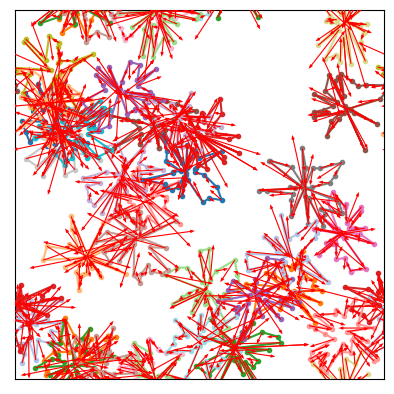

In [3]:
numPolygons = 32
n = 32
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("softBody")

m.generateRandomPolygons(numPolygons, n)
m.setBiPerimeters(kappa)
m.setStiffness(1)
m.setCompressibility(1)

m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
artists = m.draw(forces = m.getForces())

In [4]:
m.getEnergy()

1.0807019707674987

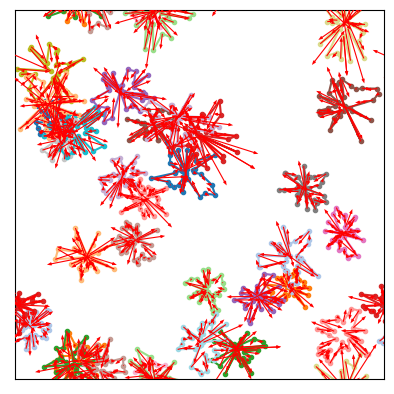

In [5]:
m.resetAreas()
m.updatePolygonGeometry()
areas = m.getAreas()
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
m.setModelEnum("softBody")
force = m.getForces()
artists = m.draw(forces = m.getForces())
m.updateForceEnergy()

In [6]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing: 100%|███████████████████████| 10000/10000 [00:04<00:00, 2348.77it/s]


4.200934880708224e-09

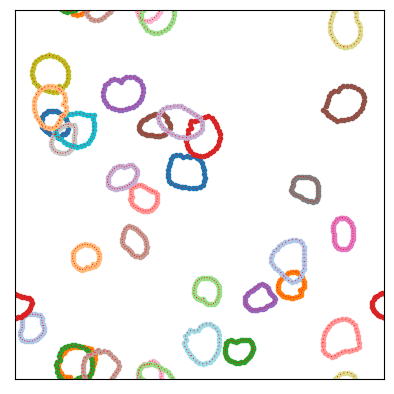

In [7]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
_ = m.draw(forces = force)

In [8]:
m.getMaxUnbalancedForce()

4.292913453431217e-07

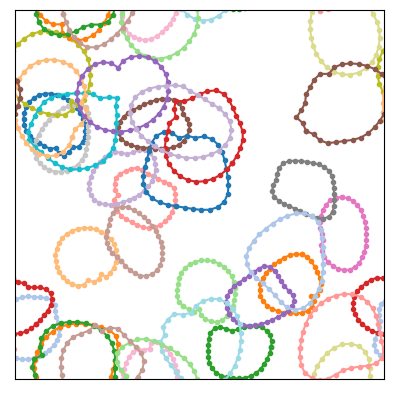

In [9]:
phi = 0.95
m.setPhi(phi)
_ = m.draw()

In [10]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

(3.737790925476422e-15, 5.455458252306871e-05)


In [11]:
#m.saveModel("SHAKETesting")

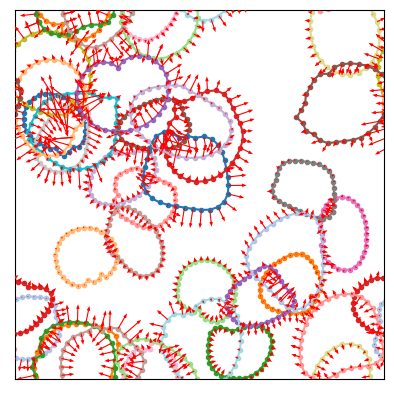

In [12]:
m.setModelEnum("normal")
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.projectForce()
forces = m.getForces()
_ = m.draw(forces = forces)

Processing: 100%|████████████████████████████████| 1/1 [00:00<00:00, 366.41it/s]


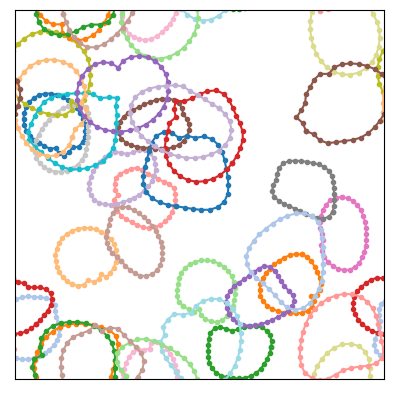

In [13]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-6, maxSteps = 0, progressBar = True)
_ = m.draw()
plt.show()

In [14]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())
numPolygons = m.getNumPolygons()
edgeLengths = m.getEdgeLengths()
nArray = m.getnArray()
startIndices = m.getStartIndices()
endIndices = np.roll(startIndices, -1)
cumulativeEdgeLengths = np.cumsum(np.concatenate(([0], edgeLengths)))
meanEdgeLength = (cumulativeEdgeLengths[endIndices[:-1]] - cumulativeEdgeLengths[startIndices[:-1]]) / nArray
print(np.max(np.abs(meanEdgeLength - m.getTargetEdgeLengths())), np.max(np.abs(m.getAreas() - m.getTargetAreas())))

#print(m.getAreas() - m.getTargetAreas(), np.mean(m.getEdgeLengths().reshape(numPolygons, ) - m.getTargetEdgeLengths())**4))

(3.737790925476422e-15, 5.455458252306871e-05)
2.451003124546297e-06 2.393918396847994e-16


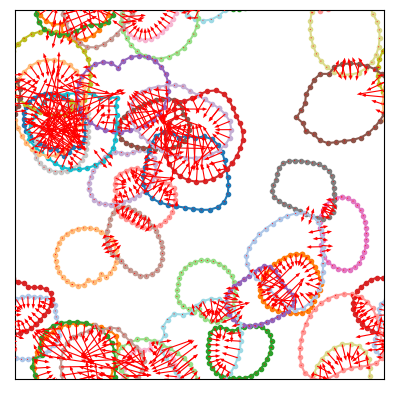

In [15]:
m.setModelEnum("normal")
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
artists = m.draw(forces = m.getForces(), arrowColor = 'r')

Processing: 100%|████████████████████████████████| 1/1 [00:00<00:00, 240.42it/s]


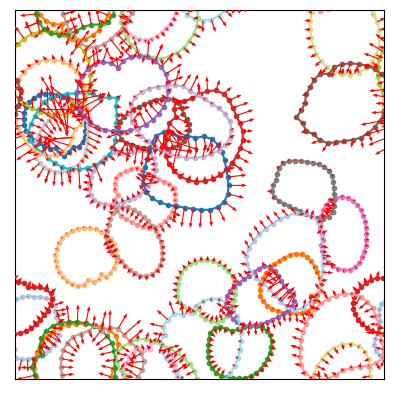

In [16]:
#for dt in np.logspace(-6, -3, 10):
#    m.setModelEnum("edgeOnly")
#    m.minimizeGD(dt = dt, maxSteps = maxSteps, progressBar = True)
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-5, maxSteps = 1, progressBar = True)
_ = m.draw(forces = m.getForces())
plt.show()

In [17]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.11064175845888262,
 0.4342776901437122,
 (6.598123451714916e-12, 5.469175329911743e-05))

In [18]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing: 100%|███████████████████████| 10000/10000 [00:04<00:00, 2324.73it/s]


1.945654565899287e-21

Processing: 100%|████████████████████████████████| 1/1 [00:00<00:00, 323.83it/s]


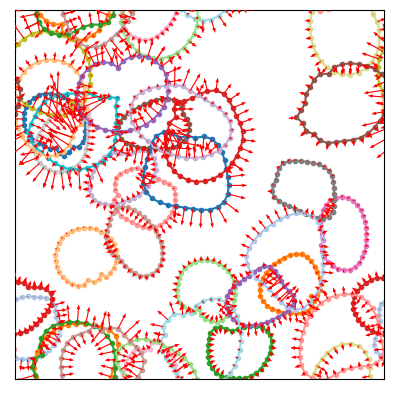

In [19]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-4, maxSteps = 1, progressBar = True)
_ = m.draw(forces = m.getForces())
plt.show()

In [20]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.12045025426078461,
 0.4342757974480844,
 (9.263529449820262e-10, 3.6248993201273127e-05))

In [21]:
def resetMinimizeGD(model, maxConstraintViolationThreshold = 0.02, maxSteps = -1):
    trials = 80
    trial = 0
    while trial < trials:
        model.setModelEnum("softBody")
        model.minimizeGD(dt = 0.1, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = maxSteps, progressBar = True)
        model.setModelEnum("normal")
        model.minimizeGD(dt = 1e-4, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = maxSteps, progressBar = True)
        trial += 1
    model.setModelEnum("softBody")
    model.minimizeGD(dt = 0.1, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = maxSteps, progressBar = True)
    model.setModelEnum("normal")
    model.minimizeGD(dt = 1e-4, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = 0, progressBar = True)


In [ ]:
resetMinimizeGD(m, maxSteps = maxSteps)

Processing:  61%|███████████████▏         | 6084/10000 [00:15<00:09, 412.12it/s]

In [ ]:
_ = m.draw(forces = m.getForces())
plt.show()

In [ ]:
m.getMaxUnbalancedForce()